# Ensemble Learning with Stacking

This project compares a small neural network, a decision tree, and a stacking
ensemble for a three-class classification problem. Logistic regression combines
the probabilities predicted by the two base models. I also compare stacking
with simply averaging their probabilities.

The aim is to understand how stacking works and whether it improves the predictions
of the individual models. An improvement is not guaranteed.


## 1. Libraries

The experiment uses Python and scikit-learn. Run the cells in order to reproduce
the tables and figures. The data is generated locally, so no download is needed.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.datasets import make_blobs
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

warnings.simplefilter('error', ConvergenceWarning)
FIGURES = Path('figures')
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})


## 2. Dataset

The dataset has 1,100 synthetic observations, two features, and three overlapping
classes. Two features make the classification problem easy to visualize.
Fixed random seeds make the generated dataset reproducible. These are simulated data, not real customer or medical records.


Samples and features: (1100, 2)
Class counts: [367 367 366]


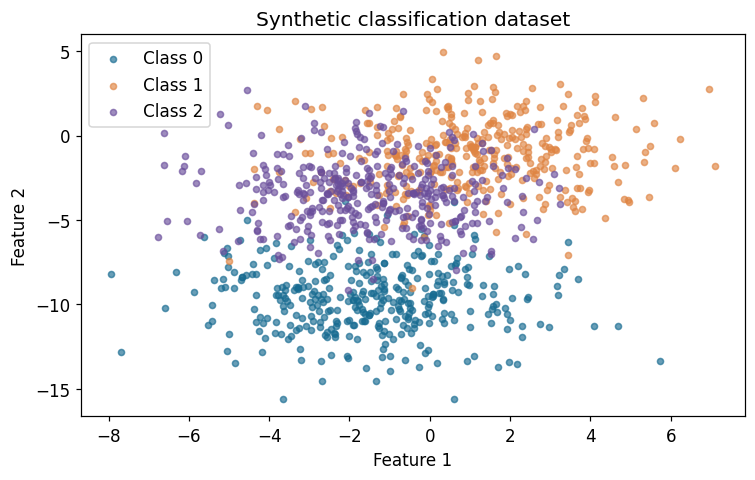

In [2]:
_, _, centers = make_blobs(n_samples=1100, centers=3, n_features=2,
                           cluster_std=2, random_state=2, return_centers=True)
X, y = make_blobs(n_samples=1100, centers=centers, cluster_std=2,
                  random_state=20260927)
print('Samples and features:', X.shape)
print('Class counts:', np.bincount(y))

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, color in enumerate(['#176b91', '#df8442', '#6a4e9b']):
    ax.scatter(X[y == label, 0], X[y == label, 1], s=16, alpha=.65,
               color=color, label=f'Class {label}')
ax.set(xlabel='Feature 1', ylabel='Feature 2', title='Synthetic classification dataset')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'dataset.png', dpi=160)
plt.show()
plt.close(fig)


## 3. Models and evaluation

- **Neural network:** one hidden layer with 25 ReLU units and the Adam optimizer.
  Features are standardized using only the current training data.
- **Decision tree:** maximum depth 2.
- **Probability averaging:** equal average of the two models' class probabilities.
- **Stacking:** logistic regression learns how to combine those probabilities.

For stacking, each sample contributes six features: three probabilities from
the neural network and three from the tree.

I use five outer folds to evaluate the models. In each fold, 220 observations are
reserved for testing. The other 880 are split into 660 training and 220 validation
observations. Validation macro-F1 chooses the logistic-regression regularization
parameter C. The models are then refitted on all 880 development observations.
Test data are not used for fitting, scaling, or selecting C.

**Why out-of-fold predictions?** The combiner should learn from predictions on
samples the base models did not train on. Otherwise, its training features can
make the base models look unrealistically accurate. Five inner folds create these
out-of-fold probabilities, including fitting the scaler inside each fold.


In [3]:
def base_models(seed):
    neural_network = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(25,), activation='relu', solver='adam',
                      max_iter=2000, n_iter_no_change=30, random_state=seed))
    tree = DecisionTreeClassifier(max_depth=2, random_state=seed)
    return [neural_network, tree]


def oof_features(models, features, labels, seed):
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    return np.hstack([
        cross_val_predict(model, features, labels, cv=folds, method='predict_proba')
        for model in models
    ])


def prediction_features(models, features):
    return np.hstack([model.predict_proba(features) for model in models])


## 4. Train and compare

The base-model settings stay fixed. Only C is chosen, from seven candidates,
using validation macro-F1; ties select the smaller C. All four methods are tested
on the same examples. Each observation receives one outer-test prediction.

Accuracy measures overall correctness. Macro-F1 gives each class equal weight
and is the main comparison metric. This cell may take a minute or two on CPU.


In [4]:
C_VALUES = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
outer_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=20260928)
predictions, fold_scores, chosen_values = [], [], []

with threadpool_limits(limits=1):
    for fold, (development, test) in enumerate(outer_folds.split(X, y)):
        seed = 3100 + fold
        train, validation = train_test_split(
            development, test_size=.25, stratify=y[development], random_state=seed)
        assert not set(development) & set(test)
        models = base_models(seed)

        # Choose C using out-of-fold training features and separate validation data.
        train_meta = oof_features(models, X[train], y[train], seed)
        fitted = [clone(model).fit(X[train], y[train]) for model in models]
        validation_meta = prediction_features(fitted, X[validation])
        best_score, best_c = -1, None
        for c in C_VALUES:
            meta = LogisticRegression(C=c, max_iter=2000, random_state=seed)
            meta.fit(train_meta, y[train])
            score = f1_score(y[validation], meta.predict(validation_meta), average='macro')
            if score > best_score:
                best_score, best_c = score, c
        chosen_values.append({'fold': fold + 1, 'C': best_c,
                              'validation_macro_f1': best_score})

        # Refit on development data, still excluding the outer test fold.
        development = np.concatenate([train, validation])
        development_meta = oof_features(models, X[development], y[development], seed)
        meta = LogisticRegression(C=best_c, max_iter=2000, random_state=seed)
        meta.fit(development_meta, y[development])
        fitted = [clone(model).fit(X[development], y[development]) for model in models]
        nn_proba, tree_proba = [model.predict_proba(X[test]) for model in fitted]
        classes = fitted[0].classes_
        predicted = {
            'Neural network': classes[nn_proba.argmax(axis=1)],
            'Decision tree': classes[tree_proba.argmax(axis=1)],
            'Probability averaging': classes[((nn_proba + tree_proba) / 2).argmax(axis=1)],
            'Stacking': meta.predict(np.hstack([nn_proba, tree_proba]))
        }
        predictions.append(pd.DataFrame({'sample_id': test, 'fold': fold + 1,
                                         'actual': y[test], **predicted}))
        for name, values in predicted.items():
            fold_scores.append({'fold': fold + 1, 'model': name,
                                'macro_f1': f1_score(y[test], values, average='macro')})
        print(f'Finished fold {fold + 1}/5')

predictions = pd.concat(predictions, ignore_index=True)
assert predictions.sample_id.nunique() == len(predictions) == len(y)
model_names = list(predicted)
results = pd.DataFrame([
    {'Model': name, 'Accuracy': accuracy_score(predictions.actual, predictions[name]),
     'Macro-F1': f1_score(predictions.actual, predictions[name], average='macro')}
    for name in model_names
]).set_index('Model')
display(results.round(4))


Finished fold 1/5


Finished fold 2/5


Finished fold 3/5


Finished fold 4/5


Finished fold 5/5


,Accuracy,Macro-F1
Model,,
Neural network,0.8382,0.8385
Decision tree,0.7764,0.7760
Probability averaging,0.8000,0.7997
Stacking,0.8318,0.8317


## 5. Results

The scores below pool the five outer test folds: each of the 1,100 samples was
predicted while excluded from training and model selection. The per-fold table
shows whether the differences are consistent across splits.


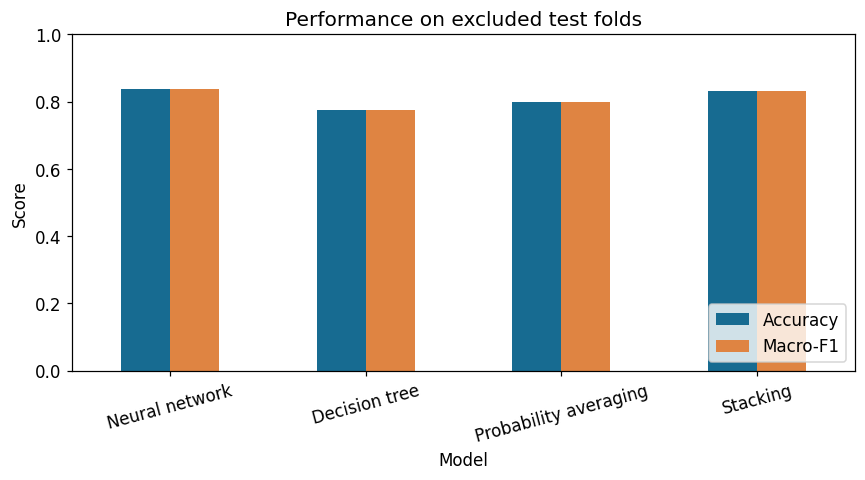

model,Decision tree,Neural network,Probability averaging,Stacking
fold,,,,
1,0.7776,0.8278,0.8185,0.8278
2,0.7391,0.8192,0.7682,0.8147
3,0.7948,0.8587,0.7988,0.8483
4,0.7817,0.8419,0.7955,0.8282
5,0.7832,0.8433,0.8157,0.8385


,fold,C,validation_macro_f1
0,1,1.0,0.8505
1,2,1.0,0.8713
2,3,0.1,0.8470
3,4,1.0,0.8592
4,5,1.0,0.8172


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
results.plot.bar(ax=ax, color=['#176b91', '#df8442'], rot=15)
ax.set(ylim=(0, 1), ylabel='Score', title='Performance on excluded test folds')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES / 'comparison.png', dpi=160)
plt.show()
plt.close(fig)
display(pd.DataFrame(fold_scores).pivot(index='fold', columns='model', values='macro_f1').round(4))
display(pd.DataFrame(chosen_values).round(4))


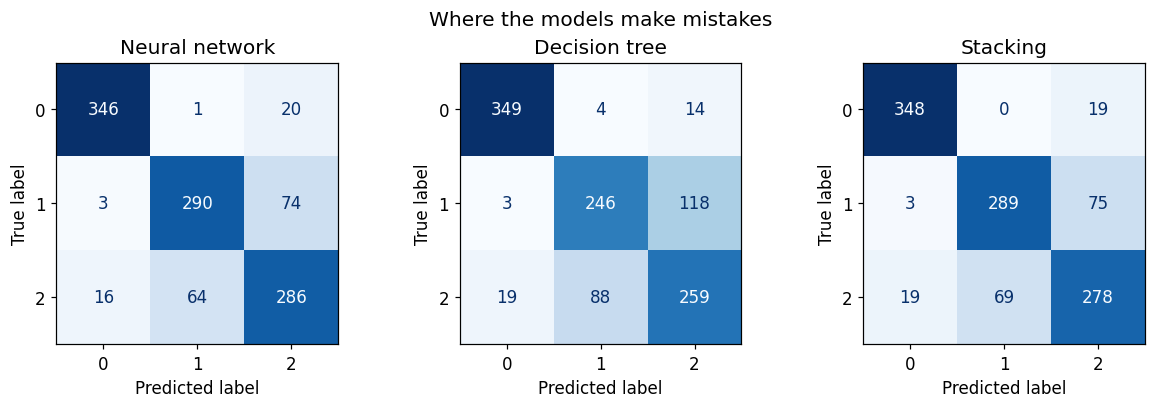

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), layout='constrained')
for ax, name in zip(axes, ['Neural network', 'Decision tree', 'Stacking']):
    ConfusionMatrixDisplay.from_predictions(predictions.actual, predictions[name],
                                             ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
fig.suptitle('Where the models make mistakes')
fig.savefig(FIGURES / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)


## 6. What did combining the models achieve?

Different predictions are useful only if one model sometimes corrects the other's
mistakes. The counts below examine that relationship. Knowing which model is
correct requires the true labels, so these counts are an explanation, not a rule
that could be used when predicting a new sample.


In [7]:
nn_correct = predictions['Neural network'] == predictions.actual
tree_correct = predictions['Decision tree'] == predictions.actual
print('Tree correct while neural network is wrong:', int((tree_correct & ~nn_correct).sum()))
print('Neural network correct while tree is wrong:', int((nn_correct & ~tree_correct).sum()))
print('Both models wrong:', int((~nn_correct & ~tree_correct).sum()))
print('Stacking minus neural-network accuracy:',
      round(100 * (results.loc['Stacking', 'Accuracy'] - results.loc['Neural network', 'Accuracy']), 2),
      'percentage points')


Tree correct while neural network is wrong: 32
Neural network correct while tree is wrong: 100
Both models wrong: 146
Stacking minus neural-network accuracy: -0.64 percentage points


## 7. Conclusion and limitations

In this experiment, the neural network had the best accuracy and macro-F1.
Stacking performed better than the tree and equal probability averaging, but
did not improve on the neural network alone. The tree corrected some of the
network's mistakes, but the combiner did not turn that into a net improvement.

The main lesson is that stacking is a method for learning how to combine models,
not a guarantee of higher accuracy. Generating proper out-of-fold predictions
and comparing against the individual models are essential parts of the experiment.

The dataset is small and synthetic, the base-model settings are fixed, and the
outer training folds overlap. These results do not demonstrate real-world
performance or statistically significant differences. Further work could study
a real tabular dataset or tune the base models using training data only.

## References

- [scikit-learn stacking documentation](https://scikit-learn.org/stable/modules/ensemble.html#stacked-generalization)
- [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
